In [3]:
!pip install -q transformers keybert sentence-transformers scikit-learn torch  bertopic python-multipart



In [2]:
from huggingface_hub import notebook_login

notebook_login()

Device set to use cpu


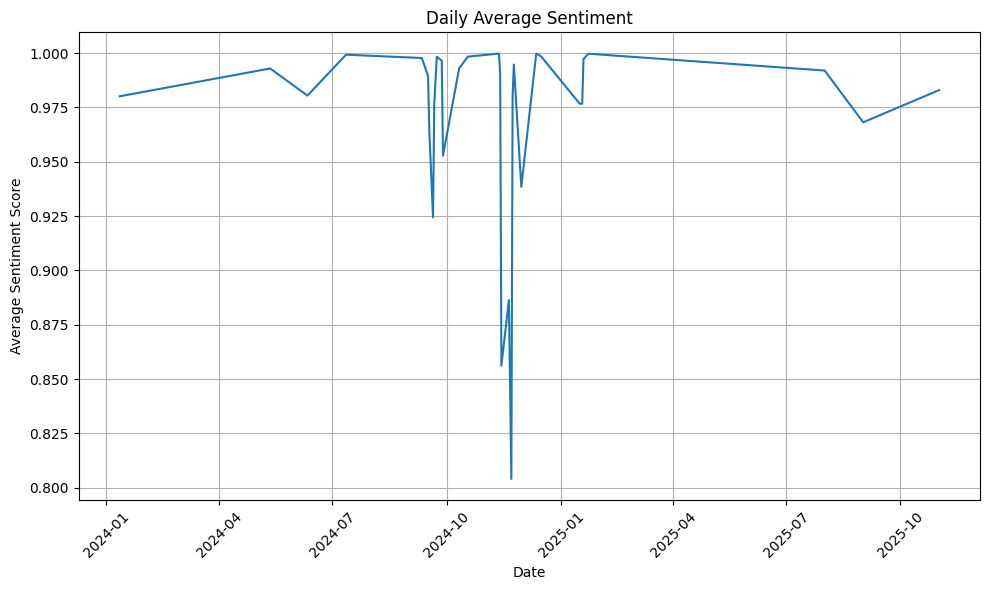

1. Average Likes per Post: 631.18
2. Average Comments per Post: 100
3. Top 7 Keywords and the Number of Posts they Appeared In: [('devtronl', 25), ('nokia', 13), ('kubernetes', 12), ('cloud', 12), ('gitops', 7), ('devtron', 7), ('kubecon', 6)]
4. Overall Sentiment Score (from Posts with highest daily sentiment): 0.9815068319439888
9. Overall Sentiment Label (from all posts): Positive
9. Overall Sentiment Score (from all posts): 0.9672097706794739


In [31]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from datetime import datetime
from transformers import pipeline
from keybert import KeyBERT
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Load the Twitter data (Make sure this includes sentiment, likes, comments, etc.)
data = pd.read_json('devtron_twitter_search.json')
data=data[:50]
# Initialize pipelines
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0  # Specify GPU for faster processing (use 0 for CPU)
)
keyword_extractor = KeyBERT()  # For extracting keywords

# Function to remove stop words
def remove_stop_words(text):
    # Tokenize the text and remove stop words
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word.lower() not in ENGLISH_STOP_WORDS]
    return " ".join(filtered_tokens)

# Function to process each tweet
def process_tweet(tweet_content):
    tweet_content_clean = remove_stop_words(tweet_content)  # Remove stop words from the tweet content

    # Extract sentiment for the tweet content
    sentiment_result = sentiment_pipeline(tweet_content_clean)
    content_sentiment = {
        "label": sentiment_result[0]["label"],
        "score": sentiment_result[0]["score"]
    }

    # Extract keywords from the tweet content
    keywords = keyword_extractor.extract_keywords(tweet_content_clean, top_n=5)
    trending_keywords = [kw[0] for kw in keywords]

    return {
        "content_sentiment": content_sentiment,
        "trending_keywords": trending_keywords
    }

# Process tweets and calculate engagement score
processed_posts = []
tweet_texts = []  # To collect content for topic modeling

for _, row in data.iterrows():
    tweet_content = row["content"]
    likes = row.get("likes", 0)  # Assuming 'likes' column exists
    shares = row.get("shares", 0)  # Assuming 'shares' column exists
    views = row.get("views", 0)  # Assuming 'views' column exists
    comments = 100  # As per the given assumption

    # Calculate engagement score
    engagement_score = likes + shares + comments + views

    processed_data = process_tweet(tweet_content)
    processed_posts.append({
        "tweet_id": row["tweet_id"],
        "content_sentiment": processed_data["content_sentiment"],
        "trending_keywords": processed_data["trending_keywords"],
        "engagement_score": engagement_score,
        "timestamp": row.get("datetime"),  # Assuming 'timestamp' exists in your dataset
    })
    tweet_texts.append(remove_stop_words(tweet_content))  # Remove stop words before topic modeling

# Convert processed_posts into a DataFrame
processed_posts_df = pd.DataFrame(processed_posts)

# Convert timestamp to datetime for daily analysis (assuming 'timestamp' exists in your dataset)
processed_posts_df['timestamp'] = pd.to_datetime(processed_posts_df['timestamp'])

# 1. Average Likes per Post
average_likes_per_post = processed_posts_df['engagement_score'].mean()

# 2. Average Comments per Post (assuming 100 comments per post)
average_comments_per_post = 100  # As per the given assumption

# 3. Top 7 Keywords and the Number of Posts They Appeared In
# Collect all keywords from the processed posts
all_keywords = [kw for sublist in processed_posts_df['trending_keywords'] for kw in sublist]
keyword_counts = Counter(all_keywords)
top_7_keywords = keyword_counts.most_common(7)

# 4. Daily Sentiment Analysis
# Extract sentiment score for each post
processed_posts_df['date'] = processed_posts_df['timestamp'].dt.date
processed_posts_df['sentiment_score'] = processed_posts_df['content_sentiment'].apply(lambda x: x['score'])

# Calculate daily average sentiment
daily_sentiment = processed_posts_df.groupby('date')['sentiment_score'].mean()

# 5. Get the post with the highest sentiment score for each day
daily_sentiment_post = processed_posts_df.loc[processed_posts_df.groupby('date')['sentiment_score'].idxmax()]

# 6. Calculate the overall sentiment from daily_sentiment_post
overall_sentiment_score = daily_sentiment_post['sentiment_score'].mean()

# 8. Calculate the overall sentiment score from all tweets
overall_sentiment_score_all_posts = processed_posts_df['sentiment_score'].mean()

# 9. Determine the overall sentiment label (positive, neutral, negative)
# Calculate the proportion of positive, neutral, and negative sentiments
positive_count = processed_posts_df[processed_posts_df['sentiment_score'] > 0.5].shape[0]
neutral_count = processed_posts_df[processed_posts_df['sentiment_score'] == 0.5].shape[0]
negative_count = processed_posts_df[processed_posts_df['sentiment_score'] < 0.5].shape[0]

# Calculate the label based on majority sentiment
if positive_count > negative_count and positive_count > neutral_count:
    overall_sentiment_label = "Positive"
elif negative_count > positive_count and negative_count > neutral_count:
    overall_sentiment_label = "Negative"
else:
    overall_sentiment_label = "Neutral"

# 7. Plot the daily sentiment graph
plt.figure(figsize=(10, 6))
daily_sentiment.plot(kind='line', title='Daily Average Sentiment')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Print results
print(f"1. Average Likes per Post: {average_likes_per_post}")
print(f"2. Average Comments per Post: {average_comments_per_post}")
print(f"3. Top 7 Keywords and the Number of Posts they Appeared In: {top_7_keywords}")
print(f"4. Overall Sentiment Score (from Posts with highest daily sentiment): {overall_sentiment_score}")
print(f"9. Overall Sentiment Label (from all posts): {overall_sentiment_label}")
print(f"9. Overall Sentiment Score (from all posts): {overall_sentiment_score_all_posts}")



In [30]:
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from datetime import datetime
from transformers import pipeline
from keybert import KeyBERT
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from io import BytesIO

# Initialize FastAPI app
app = FastAPI()

# Initialize pipelines
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0  # Specify GPU for faster processing (use 0 for CPU)
)
keyword_extractor = KeyBERT()  # For extracting keywords

# Function to remove stop words
def remove_stop_words(text):
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word.lower() not in ENGLISH_STOP_WORDS]
    return " ".join(filtered_tokens)

# Function to process each tweet
def process_tweet(tweet_content):
    tweet_content_clean = remove_stop_words(tweet_content)  # Remove stop words from the tweet content

    # Extract sentiment for the tweet content
    sentiment_result = sentiment_pipeline(tweet_content_clean)
    content_sentiment = {
        "label": sentiment_result[0]["label"],
        "score": sentiment_result[0]["score"]
    }

    # Extract keywords from the tweet content
    keywords = keyword_extractor.extract_keywords(tweet_content_clean, top_n=5)
    trending_keywords = [kw[0] for kw in keywords]

    return {
        "content_sentiment": content_sentiment,
        "trending_keywords": trending_keywords
    }

# Function to process the uploaded JSON and perform the analysis
def process_data(data):
    processed_posts = []
    tweet_texts = []  # To collect content for topic modeling

    for _, row in data.iterrows():
        tweet_content = row["content"]
        likes = row.get("likes", 0)
        shares = row.get("shares", 0)
        views = row.get("views", 0)
        comments = 100  # Assumed value

        # Calculate engagement score
        engagement_score = likes + shares + comments + views

        processed_data = process_tweet(tweet_content)
        processed_posts.append({
            "tweet_id": row["tweet_id"],
            "content_sentiment": processed_data["content_sentiment"],
            "trending_keywords": processed_data["trending_keywords"],
            "engagement_score": engagement_score,
            "timestamp": row.get("datetime"),
        })
        tweet_texts.append(remove_stop_words(tweet_content))  # Remove stop words before topic modeling

    processed_posts_df = pd.DataFrame(processed_posts)

    # Convert timestamp to datetime for daily analysis
    processed_posts_df['timestamp'] = pd.to_datetime(processed_posts_df['timestamp'])

    # Calculations
    average_likes_per_post = processed_posts_df['engagement_score'].mean()
    average_comments_per_post = 100  # Assumed value

    # Top 7 Keywords
    all_keywords = [kw for sublist in processed_posts_df['trending_keywords'] for kw in sublist]
    keyword_counts = Counter(all_keywords)
    top_7_keywords = keyword_counts.most_common(7)

    # Daily Sentiment Analysis
    processed_posts_df['date'] = processed_posts_df['timestamp'].dt.date
    processed_posts_df['sentiment_score'] = processed_posts_df['content_sentiment'].apply(lambda x: x['score'])

    daily_sentiment = processed_posts_df.groupby('date')['sentiment_score'].mean()

    daily_sentiment_post = processed_posts_df.loc[processed_posts_df.groupby('date')['sentiment_score'].idxmax()]

    overall_sentiment_score = daily_sentiment_post['sentiment_score'].mean()
    overall_sentiment_score_all_posts = processed_posts_df['sentiment_score'].mean()

    # Overall Sentiment Label
    positive_count = processed_posts_df[processed_posts_df['sentiment_score'] > 0.5].shape[0]
    neutral_count = processed_posts_df[processed_posts_df['sentiment_score'] == 0.5].shape[0]
    negative_count = processed_posts_df[processed_posts_df['sentiment_score'] < 0.5].shape[0]

    if positive_count > negative_count and positive_count > neutral_count:
        overall_sentiment_label = "Positive"
    elif negative_count > positive_count and negative_count > neutral_count:
        overall_sentiment_label = "Negative"
    else:
        overall_sentiment_label = "Neutral"

    return {
        "average_likes_per_post": average_likes_per_post,
        "average_comments_per_post": average_comments_per_post,
        "top_7_keywords": top_7_keywords,
        "overall_sentiment_score": overall_sentiment_score,
        "overall_sentiment_label": overall_sentiment_label,
        "overall_sentiment_score_all_posts": overall_sentiment_score_all_posts,
        "daily_sentiment": daily_sentiment.to_dict(),
    }

# Endpoint to upload the JSON file
@app.post("/upload/")
async def upload_file(file: UploadFile = File(...)):
    contents = await file.read()
    # Load the JSON data
    data = pd.read_json(BytesIO(contents))

    # Process the data
    analysis_result = process_data(data)

    return JSONResponse(content=analysis_result)

# Endpoint to return graph as a base64 image (optional)
@app.post("/plot_sentiment/")
async def plot_sentiment(file: UploadFile = File(...)):
    contents = await file.read()
    # Load the JSON data
    data = pd.read_json(BytesIO(contents))

    # Process the data
    processed_posts_df = pd.DataFrame(process_data(data)['daily_sentiment'])

    # Plotting the sentiment graph
    plt.figure(figsize=(10, 6))
    processed_posts_df.plot(kind='line', title='Daily Average Sentiment')
    plt.xlabel('Date')
    plt.ylabel('Average Sentiment Score')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    # Save the plot to a BytesIO object
    img = BytesIO()
    plt.savefig(img, format="png")
    img.seek(0)

    # Return the image as base64 string
    import base64
    img_base64 = base64.b64encode(img.read()).decode('utf-8')

    return JSONResponse(content={"image": img_base64})

# To run the app, use the command: uvicorn app_name:app --reload


PyngrokNgrokHTTPError: ngrok client exception, API returned 400: {"error_code":102,"status_code":400,"msg":"invalid tunnel configuration","details":{"err":"yaml: unmarshal errors:\n  line 1: field options not found in type config.HTTPv2Tunnel"}}


In [26]:
import nest_asyncio
from pyngrok import ngrok
import uvicorn

ngrok_tunnel = ngrok.connect(8000)
print('Public URL:', ngrok_tunnel.public_url)
nest_asyncio.apply()
uvicorn.run(app, port=8000)

Public URL: https://9959-34-106-196-38.ngrok-free.app


INFO:     Started server process [155]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


INFO:     103.80.23.144:0 - "GET / HTTP/1.1" 404 Not Found
INFO:     103.80.23.144:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     103.80.23.144:0 - "GET /twitter_analyses HTTP/1.1" 405 Method Not Allowed


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [155]
